# Ba-138 Fluorescence — Alternating Lasers (Repeat Until Stable)

Time-domain Lindblad master equation simulation of Ba-138 fluorescence under
alternating 493 nm and 650 nm laser pulses, iterated until cycle-to-cycle
steady state is reached.

## Level structure

Ba-138 has no nuclear spin, so levels split only into magnetic sublevels $m_J$.
The 8-level system modelled here is:

| Index | State     | $m_J$  | Role |
|-------|-----------|--------|------|
| 0     | S$_{1/2}$ | $-1/2$ | bright ground state |
| 1     | S$_{1/2}$ | $+1/2$ | bright ground state |
| 2     | D$_{3/2}$ | $-3/2$ | metastable (dark) state |
| 3     | D$_{3/2}$ | $-1/2$ | metastable (dark) state |
| 4     | D$_{3/2}$ | $+1/2$ | metastable (dark) state |
| 5     | D$_{3/2}$ | $+3/2$ | metastable (dark) state |
| 6     | P$_{1/2}$ | $-1/2$ | excited state ($\gamma_S + \gamma_D = 126.3$ MHz) |
| 7     | P$_{1/2}$ | $+1/2$ | excited state |

## Measurement cycle

Each cycle alternates two laser pulses:
- **493 nm pulse** (duration `S_pump_turn_on_time`): drives S$_{1/2}$ $\leftrightarrow$ P$_{1/2}$
- **650 nm pulse** (duration `D_pump_turn_on_time`): drives D$_{3/2}$ $\leftrightarrow$ P$_{1/2}$

The outer loop repeats cycles until the per-cycle shelving and repump
probabilities change by less than 0.01 % for 6 consecutive cycles.

## Method

The 8×8 density matrix $\rho$ is stored as a 64-element column vector.
Two evolution matrices (`Evol_Matrix_pumpS`, `Evol_Matrix_pumpD`) encode the
full Lindblad equation $d\rho/dt = L\rho$ for each laser phase. Each cycle is
integrated with 4th-order Runge-Kutta at an adaptive time step $dt$ that
resolves both the fastest Rabi oscillation and the shorter laser pulse.

Python translation of `Ba138_fluorescence_alt_lasers_repeat_till_stable.m`.

In [1]:
import numpy as np
from math import sqrt, cos, sin, log10, ceil
import matplotlib.pyplot as plt

## Helper: build the Lindblad evolution matrix

Constructs the 64×64 matrix $L$ such that $d\rho_{\rm vec}/dt = L\,\rho_{\rm vec}$
for a given pair of Rabi frequencies.

**Density matrix indexing.**  Element $\rho_{ij}$ sits at row
$8(i-1)+j$ of the vectorised density matrix.  The Kronecker-product
vectors `c[i]` (row selector) and `c_conj[j]` (column selector)
satisfy `c[i] * c_conj[j] == 1` at exactly that position.

**Evolution matrix rows.**  For element $\rho_{ij}$:

$$\frac{d\rho_{ij}}{dt} = \underbrace{(\dot{c}_i)\,c_j^* + c_i\,(\dot{c}_j)^*}_{\text{Hamiltonian}} + \underbrace{\text{Lindblad decay terms}}_{\text{spontaneous emission}}$$

**Spontaneous emission branching fractions** from P$_{1/2}$ (from Clebsch-Gordan coefficients):

| Decay channel | Rate |
|---|---|
| p0 → s0 | $(1/3)\,\gamma_S$ |
| p0 → s1 | $(2/3)\,\gamma_S$ |
| p1 → s0 | $(2/3)\,\gamma_S$ |
| p1 → s1 | $(1/3)\,\gamma_S$ |
| p0 → d0 | $(1/2)\,\gamma_D$ |
| p0 → d1, p1 → d1 | $(1/3)\,\gamma_D$, $(1/6)\,\gamma_D$ |
| p0 → d2, p1 → d2 | $(1/6)\,\gamma_D$, $(1/3)\,\gamma_D$ |
| p1 → d3 | $(1/2)\,\gamma_D$ |

**Coherence decoherence rate** involving $k$ P-state indices: $-(k/2)(\gamma_S+\gamma_D)$.

In [2]:
def build_evol_matrix(Omega_S, Omega_D, theta_s, theta_d,
                      Delta_SP01, Delta_DP01,
                      Delta_zs, Delta_zd, Delta_zp,
                      gamma_S, gamma_D):
    """
    Build the 64x64 Lindblad evolution matrix for the 8-level Ba-138
    S-P-D system under simultaneous CW driving at Omega_S (493 nm)
    and Omega_D (650 nm).

    Parameters
    ----------
    Omega_S, Omega_D : float
        Rabi frequencies for 493 nm and 650 nm lasers (rad/MHz).
    theta_s, theta_d : float
        Polarisation angles from B-field axis (rad).
        theta=0: equal sigma-/sigma+; theta=pi/2: pure pi.
    Delta_SP01, Delta_DP01 : float
        Laser detunings from lowest-mJ S-P and D-P transitions (rad/MHz).
    Delta_zs, Delta_zd, Delta_zp : float
        Zeeman energy spacings between adjacent sublevels (rad/MHz).
    gamma_S, gamma_D : float
        Partial P1/2 decay rates to S1/2 and D3/2 (MHz).

    Returns
    -------
    E : ndarray, shape (64, 64), complex
        Lindblad evolution matrix.
    """
    n = 8

    # Laser polarisation components (sigma-, pi, sigma+)
    pol_minus_s = sqrt(cos(theta_s)**2 / 2)
    pol_0_s     = sqrt(sin(theta_s)**2)
    pol_plus_s  = sqrt(cos(theta_s)**2 / 2)
    pol_minus_d = sqrt(cos(theta_d)**2 / 2)
    pol_0_d     = sqrt(sin(theta_d)**2)
    pol_plus_d  = sqrt(cos(theta_d)**2 / 2)

    # Basis vectors and Kronecker-product index masks
    states = [np.zeros(n) for _ in range(n)]
    for i in range(n):
        states[i][i] = 1.0
    c      = [np.kron(s, np.ones(n)) for s in states]  # row selectors
    c_conj = [np.kron(np.ones(n), s) for s in states]  # column selectors
    cs0, cs1, cd0, cd1, cd2, cd3, cp0, cp1             = c
    cs0_c, cs1_c, cd0_c, cd1_c, cd2_c, cd3_c, cp0_c, cp1_c = c_conj

    # Hamiltonian coupling vectors: dc_x/dt in the RWA rotating frame.
    # Each row encodes: energy shift (detuning + Zeeman) + coupling via CG coefficients.
    # CG coefficients for S1/2 <-> P1/2:
    #   S(mJ=-1/2) <-> P(mJ=-1/2): pi,     sqrt(1/3)
    #   S(mJ=-1/2) <-> P(mJ=+1/2): sigma+, sqrt(2/3)
    #   S(mJ=+1/2) <-> P(mJ=-1/2): sigma-, sqrt(2/3)
    #   S(mJ=+1/2) <-> P(mJ=+1/2): pi,     sqrt(1/3)
    cs0_prime = (-1j * Delta_SP01 * cs0
                 + 1j * (Omega_S / 2) * (sqrt(1/3) * pol_0_s * cp0
                                         + sqrt(2/3) * pol_plus_s * cp1))
    cs0_prime_c = np.conj(-1j * Delta_SP01 * cs0_c
                          + 1j * (Omega_S / 2) * (sqrt(1/3) * pol_0_s * cp0_c
                                                   + sqrt(2/3) * pol_plus_s * cp1_c))

    cs1_prime = (-1j * (Delta_SP01 + Delta_zs) * cs1
                 - 1j * (Omega_S / 2) * (sqrt(2/3) * pol_minus_s * cp0
                                         + sqrt(1/3) * pol_0_s * cp1))
    cs1_prime_c = np.conj(-1j * (Delta_SP01 + Delta_zs) * cs1_c
                          - 1j * (Omega_S / 2) * (sqrt(2/3) * pol_minus_s * cp0_c
                                                   + sqrt(1/3) * pol_0_s * cp1_c))

    # CG coefficients for D3/2 <-> P1/2 (non-zero channels only):
    #   D(mJ=-3/2) <-> P(mJ=-1/2): sigma+, sqrt(1/2)
    #   D(mJ=-1/2) <-> P(mJ=-1/2): pi,     sqrt(1/3)  (minus sign from CG convention)
    #   D(mJ=-1/2) <-> P(mJ=+1/2): sigma+, sqrt(1/6)
    #   D(mJ=+1/2) <-> P(mJ=-1/2): sigma-, sqrt(1/6)
    #   D(mJ=+1/2) <-> P(mJ=+1/2): pi,     sqrt(1/3)  (minus sign from CG convention)
    #   D(mJ=+3/2) <-> P(mJ=+1/2): sigma-, sqrt(1/2)
    cd0_prime = (-1j * Delta_DP01 * cd0
                 - 1j * (Omega_D / 2) * sqrt(1/2) * pol_plus_d * cp0)
    cd0_prime_c = np.conj(-1j * Delta_DP01 * cd0_c
                          - 1j * (Omega_D / 2) * sqrt(1/2) * pol_plus_d * cp0_c)

    cd1_prime = (-1j * (Delta_DP01 + Delta_zd) * cd1
                 - 1j * (Omega_D / 2) * (sqrt(1/6) * pol_plus_d * cp1
                                         - sqrt(1/3) * pol_0_d * cp0))
    cd1_prime_c = np.conj(-1j * (Delta_DP01 + Delta_zd) * cd1_c
                          - 1j * (Omega_D / 2) * (sqrt(1/6) * pol_plus_d * cp1_c
                                                   - sqrt(1/3) * pol_0_d * cp0_c))

    cd2_prime = (-1j * (Delta_DP01 + 2 * Delta_zd) * cd2
                 - 1j * (Omega_D / 2) * (sqrt(1/6) * pol_minus_d * cp0
                                         - sqrt(1/3) * pol_0_d * cp1))
    cd2_prime_c = np.conj(-1j * (Delta_DP01 + 2 * Delta_zd) * cd2_c
                          - 1j * (Omega_D / 2) * (sqrt(1/6) * pol_minus_d * cp0_c
                                                   - sqrt(1/3) * pol_0_d * cp1_c))

    cd3_prime = (-1j * (Delta_DP01 + 3 * Delta_zd) * cd3
                 - 1j * (Omega_D / 2) * sqrt(1/2) * pol_minus_d * cp1)
    cd3_prime_c = np.conj(-1j * (Delta_DP01 + 3 * Delta_zd) * cd3_c
                          - 1j * (Omega_D / 2) * sqrt(1/2) * pol_minus_d * cp1_c)

    # P1/2 states are driven by both lasers simultaneously.
    # Energy reference: p0 shifted by +Delta_zp; p1 at the rotating-frame origin.
    cp0_prime = (1j * Delta_zp * cp0
                 - 1j * (Omega_S / 2) * (sqrt(2/3) * pol_minus_s * cs1
                                         - sqrt(1/3) * pol_0_s * cs0)
                 - 1j * (Omega_D / 2) * (sqrt(1/2) * pol_plus_d * cd0
                                         - sqrt(1/3) * pol_0_d * cd1
                                         + sqrt(1/6) * pol_minus_d * cd2))
    cp0_prime_c = np.conj(1j * Delta_zp * cp0_c
                          - 1j * (Omega_S / 2) * (sqrt(2/3) * pol_minus_s * cs1_c
                                                   - sqrt(1/3) * pol_0_s * cs0_c)
                          - 1j * (Omega_D / 2) * (sqrt(1/2) * pol_plus_d * cd0_c
                                                   - sqrt(1/3) * pol_0_d * cd1_c
                                                   + sqrt(1/6) * pol_minus_d * cd2_c))

    cp1_prime = (- 1j * (Omega_S / 2) * (sqrt(1/3) * pol_0_s * cs1
                                          - sqrt(2/3) * pol_plus_s * cs0)
                 - 1j * (Omega_D / 2) * (sqrt(1/6) * pol_plus_d * cd1
                                          - sqrt(1/3) * pol_0_d * cd2
                                          + sqrt(1/2) * pol_minus_d * cd3))
    cp1_prime_c = np.conj(- 1j * (Omega_S / 2) * (sqrt(1/3) * pol_0_s * cs1_c
                                                    - sqrt(2/3) * pol_plus_s * cs0_c)
                          - 1j * (Omega_D / 2) * (sqrt(1/6) * pol_plus_d * cd1_c
                                                   - sqrt(1/3) * pol_0_d * cd2_c
                                                   + sqrt(1/2) * pol_minus_d * cd3_c))

    primes   = [cs0_prime,   cs1_prime,   cd0_prime,   cd1_prime,
                cd2_prime,   cd3_prime,   cp0_prime,   cp1_prime]
    primes_c = [cs0_prime_c, cs1_prime_c, cd0_prime_c, cd1_prime_c,
                cd2_prime_c, cd3_prime_c, cp0_prime_c, cp1_prime_c]

    ndm = n * n
    E = np.zeros((ndm, ndm), dtype=complex)

    # --- Diagonal population equations ---
    # d(rho_xx)/dt = Hamiltonian terms + incoherent gain from P1/2 decay
    E[cs0 * cs0_c == 1, :] = (cs0 * cs0_prime_c + cs0_prime * cs0_c
                               + (1/3) * gamma_S * cp0 * cp0_c
                               + (2/3) * gamma_S * cp1 * cp1_c)
    E[cs1 * cs1_c == 1, :] = (cs1 * cs1_prime_c + cs1_prime * cs1_c
                               + (2/3) * gamma_S * cp0 * cp0_c
                               + (1/3) * gamma_S * cp1 * cp1_c)
    E[cd0 * cd0_c == 1, :] = (cd0 * cd0_prime_c + cd0_prime * cd0_c
                               + (1/2) * gamma_D * cp0 * cp0_c)
    E[cd1 * cd1_c == 1, :] = (cd1 * cd1_prime_c + cd1_prime * cd1_c
                               + (1/3) * gamma_D * cp0 * cp0_c
                               + (1/6) * gamma_D * cp1 * cp1_c)
    E[cd2 * cd2_c == 1, :] = (cd2 * cd2_prime_c + cd2_prime * cd2_c
                               + (1/6) * gamma_D * cp0 * cp0_c
                               + (1/3) * gamma_D * cp1 * cp1_c)
    E[cd3 * cd3_c == 1, :] = (cd3 * cd3_prime_c + cd3_prime * cd3_c
                               + (1/2) * gamma_D * cp1 * cp1_c)
    E[cp0 * cp0_c == 1, :] = (cp0 * cp0_prime_c + cp0_prime * cp0_c
                               - (gamma_S + gamma_D) * cp0 * cp0_c)
    E[cp1 * cp1_c == 1, :] = (cp1 * cp1_prime_c + cp1_prime * cp1_c
                               - (gamma_S + gamma_D) * cp1 * cp1_c)

    # --- Off-diagonal coherence equations ---
    # Decoherence rate = -(p_count / 2) * (gamma_S + gamma_D), where
    # p_count is the number of P1/2 state indices in the pair (i, j).
    # Indices 6 and 7 are p0 and p1.
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            mask    = c[i] * c_conj[j] == 1
            p_count = (1 if i >= 6 else 0) + (1 if j >= 6 else 0)
            E[mask, :] = (c[i] * primes_c[j] + primes[i] * c_conj[j]
                          - (p_count / 2) * (gamma_S + gamma_D) * c[i] * c_conj[j])

    return E

## Main simulation function

Builds two evolution matrices (one per laser phase), then iterates
493 nm + 650 nm cycles using RK4 until steady state.

**Convergence criterion:** the change in per-cycle shelving probability
($\Delta N_D$ during the 493 nm pulse) **and** the change in repump
probability ($\Delta N_S$ during the 650 nm pulse) are both less than
0.01 % of their current values, for 6 cumulative cycles.

**Time step** is chosen as the smaller of:
- $10^{-\lceil \log_{10}\Omega_{\rm max} \rceil}$ µs (resolves the fastest Rabi period by ~10 steps), and
- $\min(T_S, T_D) / 10$ µs (at least 10 steps inside the shorter pulse).

In [3]:
def ba138_fluorescence_alt_lasers_repeat_till_stable(
        S_pump_turn_on_time,
        D_pump_turn_on_time,
        Omega_S0=2 * np.pi * 1000,
        Omega_D0=2 * np.pi * 14,
        B_field=1.9,
        Delta_SP01=0.0,
        Delta_DP01=-2 * np.pi * 4.0776,
        theta_s=0.0,
        theta_d=0.0,
        init_state_idx=0):
    """
    Time-domain Lindblad simulation of Ba-138 under alternating 493/650 nm
    pulses, iterated until cycle-to-cycle steady state.

    Parameters
    ----------
    S_pump_turn_on_time : float
        Duration of 493 nm (S-pumping) pulse per cycle (us).
    D_pump_turn_on_time : float
        Duration of 650 nm (D-pumping) pulse per cycle (us).
    Omega_S0 : float
        493 nm Rabi frequency (rad/MHz). Default 2*pi*1000.
    Omega_D0 : float
        650 nm Rabi frequency (rad/MHz). Default 2*pi*14.
    B_field : float
        Magnetic field strength (Gauss). Default 1.9 G.
    Delta_SP01 : float
        493 nm laser detuning from S(mJ=-1/2)<->P(mJ=-1/2) (rad/MHz).
    Delta_DP01 : float
        650 nm laser detuning from D(mJ=-3/2)<->P(mJ=-1/2) (rad/MHz).
    theta_s, theta_d : float
        Polarisation angles from B-field axis (rad). theta=0: linear perp.
    init_state_idx : int
        Initial sublevel index (0 = s0 = S1/2 mJ=-1/2).

    Returns
    -------
    rho_t : ndarray, shape (64, n_time)
        Vectorised density matrix at each time step of the final converged cycle.
    time : ndarray, shape (n_time,)
        Time axis for one cycle (us), starting at 0.
    pump_time_ind : ndarray, shape (n_time,)
        Laser indicator: 1 = 493 nm on, 0 = 650 nm on, nan at t=0.
    pump_prob_S : float
        Converged shelving probability (net D population gain per 493 pulse).
    pump_prob_D : float
        Converged repump probability (net S population gain per 650 pulse).
    """
    # --- Physical constants and Zeeman splittings ---
    Planck_h = 6.62607015e-34          # J*s
    uB       = 9.274009994e-24         # J/T
    B        = B_field * 1e-4          # Gauss -> Tesla
    # g_J values: S1/2=2, D3/2=4/5, P1/2=2/3
    # Delta_z* = 2*pi * 1e-6 * g_J * uB * B / Planck_h  (rad/MHz)
    Delta_zs = 2 * np.pi * 1e-6 * 2       * uB * B / Planck_h
    Delta_zd = 2 * np.pi * 1e-6 * (4 / 5) * uB * B / Planck_h
    Delta_zp = 2 * np.pi * 1e-6 * (2 / 3) * uB * B / Planck_h

    gamma_S = 95.3   # P1/2 -> S1/2 partial decay rate (MHz)
    gamma_D = 31.0   # P1/2 -> D3/2 partial decay rate (MHz)

    # --- Build one evolution matrix per laser phase ---
    shared = dict(
        theta_s=theta_s, theta_d=theta_d,
        Delta_SP01=Delta_SP01, Delta_DP01=Delta_DP01,
        Delta_zs=Delta_zs, Delta_zd=Delta_zd, Delta_zp=Delta_zp,
        gamma_S=gamma_S, gamma_D=gamma_D)
    Evol_Matrix_pumpS = build_evol_matrix(Omega_S=Omega_S0, Omega_D=0,        **shared)
    Evol_Matrix_pumpD = build_evol_matrix(Omega_S=0,        Omega_D=Omega_D0, **shared)

    # --- Adaptive time step ---
    Omega_max      = max(abs(Omega_S0), abs(Omega_D0))
    dt_Omega       = 10 ** (-ceil(log10(Omega_max)))         # resolves fastest Rabi period
    dt_pulse       = min(S_pump_turn_on_time,
                         D_pump_turn_on_time) / 10           # >=10 steps in shorter pulse
    dt             = min(dt_Omega, dt_pulse)

    # --- Pump timing sequence ---
    # pump_time_ind: 1 = 493 nm on (S pump), 0 = 650 nm on (D pump)
    n_steps        = round((S_pump_turn_on_time + D_pump_turn_on_time) / dt)
    pti_base       = np.zeros(n_steps)
    pti_base[:round(S_pump_turn_on_time / dt)] = 1
    time           = np.concatenate([[0.0], np.linspace(dt, n_steps * dt, n_steps)])
    pump_time_ind  = np.concatenate([[np.nan], pti_base])    # prepend nan to align with t=0

    # --- Initial density matrix: pure state |init><init| as 64-element column vector ---
    n     = 8
    e     = np.zeros(n); e[init_state_idx] = 1.0
    init_c = (np.kron(e, np.ones(n)) * np.kron(np.ones(n), e)).astype(complex)
    rho_t  = np.full((n * n, len(time)), np.nan, dtype=complex)
    rho_t[:, 0]  = init_c
    rho_t[:, -1] = init_c   # placeholder; overwritten on first outer loop pass

    # --- Index masks for extracting level populations ---
    states_b = [np.zeros(n) for _ in range(n)]
    for i in range(n):
        states_b[i][i] = 1.0
    cb      = [np.kron(s, np.ones(n)) for s in states_b]
    cb_conj = [np.kron(np.ones(n), s) for s in states_b]

    def s_pop(col):  # sum of S1/2 populations
        return (col[cb[0] * cb_conj[0] == 1].real[0]
              + col[cb[1] * cb_conj[1] == 1].real[0])

    def d_pop(col):  # sum of D3/2 populations
        return sum(col[cb[i] * cb_conj[i] == 1].real[0] for i in range(2, 6))

    # --- Convergence state ---
    pump_prob_S   = 100.0
    pump_prob_D   = 100.0
    stable_count  = 0

    # -------------------------------------------------------------------------
    # Outer loop: repeat cycles until pump probabilities converge.
    # The final density matrix of each cycle seeds the next cycle.
    # -------------------------------------------------------------------------
    while stable_count < 6:
        rho_t[:, 0] = rho_t[:, -1]    # seed from end of previous cycle

        S_pop_initial = D_pop_initial = np.nan
        S_pop_final   = D_pop_final   = np.nan

        for t_idx in range(1, len(time)):
            rho_prev = rho_t[:, t_idx - 1]

            # Record population at the very start of the first laser phase
            if t_idx == 1:
                if pump_time_ind[t_idx] == 0:    # cycle starts with D-pump
                    S_pop_initial = s_pop(rho_prev)
                else:                            # cycle starts with S-pump (normal)
                    D_pop_initial = d_pop(rho_prev)

            # Detect laser switch-overs and record boundary populations
            prev_ind = pump_time_ind[t_idx - 1]
            curr_ind = pump_time_ind[t_idx]
            if not (np.isnan(prev_ind) or np.isnan(curr_ind)):
                delta = round(curr_ind - prev_ind)
                if delta == -1:    # 493 nm -> 650 nm switch
                    D_pop_final   = d_pop(rho_prev)   # D pop at end of 493 pulse
                    S_pop_initial = s_pop(rho_prev)   # S pop at start of 650 pulse
                elif delta == 1:   # 650 nm -> 493 nm switch
                    S_pop_final   = s_pop(rho_prev)   # S pop at end of 650 pulse
                    D_pop_initial = d_pop(rho_prev)   # D pop at start of 493 pulse

            # Select evolution matrix for this time step
            E = Evol_Matrix_pumpS if curr_ind == 1 else Evol_Matrix_pumpD

            # 4th-order Runge-Kutta step: d(rho)/dt = E @ rho
            k1 = E @ rho_prev
            k2 = E @ (rho_prev + (dt / 2) * k1)
            k3 = E @ (rho_prev + (dt / 2) * k2)
            k4 = E @ (rho_prev + dt * k3)
            rho_t[:, t_idx] = rho_prev + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

            # End of cycle: record final population and check convergence
            if t_idx == len(time) - 1:
                if curr_ind == 0:
                    S_pop_final = s_pop(rho_t[:, t_idx])
                else:
                    D_pop_final = d_pop(rho_t[:, t_idx])

                # Shelving probability: net D gain during 493 pulse
                # Repump probability:  net S gain during 650 pulse
                new_prob_S = D_pop_final   - D_pop_initial
                new_prob_D = S_pop_final   - S_pop_initial

                change_S = abs(pump_prob_S - new_prob_S)
                change_D = abs(pump_prob_D - new_prob_D)

                if (change_S < 0.0001 * abs(new_prob_S)
                        and change_D < 0.0001 * abs(new_prob_D)):
                    stable_count += 1

                pump_prob_S = new_prob_S
                pump_prob_D = new_prob_D

    return rho_t, time, pump_time_ind, pump_prob_S, pump_prob_D

## Example: 0.5 µs pulses at default Rabi frequencies

Default parameters match the MATLAB script:
- $B = 1.9$ G, $\theta_s = \theta_d = 0$ (linear polarisation perpendicular to $B$)
- $\Omega_S = 2\pi\times1000$ rad/MHz (strongly saturating 493 nm laser)
- $\Omega_D = 2\pi\times14$ rad/MHz (650 nm repump laser)
- $\Delta_{SP} = 0$, $\Delta_{DP} = -2\pi\times4.0776$ rad/MHz

In [6]:
S_pump_turn_on_time = 0.5   # us — duration of 493 nm pulse
D_pump_turn_on_time = 0.5   # us — duration of 650 nm pulse

rho_t, time, pump_time_ind, pump_prob_S, pump_prob_D = \
    ba138_fluorescence_alt_lasers_repeat_till_stable(
        S_pump_turn_on_time, D_pump_turn_on_time)

print(f"Converged shelving probability  (D gain during 493 pulse): {pump_prob_S:.4f}")
print(f"Converged repump probability    (S gain during 650 pulse): {pump_prob_D:.4f}")

Converged shelving probability  (D gain during 493 pulse): 0.9119
Converged repump probability    (S gain during 650 pulse): 0.9079


## Plot: population dynamics over the final converged cycle

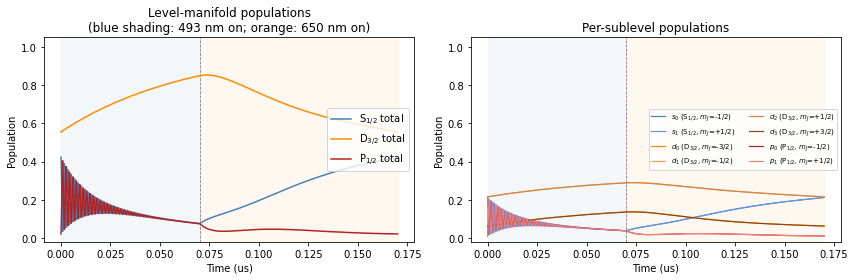

In [5]:
# Extract diagonal populations from the vectorised density matrix
n = 8
states_b = [np.zeros(n) for _ in range(n)]
for i in range(n):
    states_b[i][i] = 1.0
cb      = [np.kron(s, np.ones(n)) for s in states_b]
cb_conj = [np.kron(np.ones(n), s) for s in states_b]

pop = np.array([rho_t[cb[i] * cb_conj[i] == 1, :].real.squeeze() for i in range(n)])

S_pop = pop[0] + pop[1]                       # s0 + s1
D_pop = pop[2] + pop[3] + pop[4] + pop[5]     # d0 + d1 + d2 + d3
P_pop = pop[6] + pop[7]                        # p0 + p1

switch_time = S_pump_turn_on_time
labels = [r'$s_0$ (S$_{1/2}$, $m_J$=-1/2)', r'$s_1$ (S$_{1/2}$, $m_J$=+1/2)',
          r'$d_0$ (D$_{3/2}$, $m_J$=-3/2)', r'$d_1$ (D$_{3/2}$, $m_J$=-1/2)',
          r'$d_2$ (D$_{3/2}$, $m_J$=+1/2)', r'$d_3$ (D$_{3/2}$, $m_J$=+3/2)',
          r'$p_0$ (P$_{1/2}$, $m_J$=-1/2)', r'$p_1$ (P$_{1/2}$, $m_J$=+1/2)']

# --- Panel 1: level-manifold totals ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.axvspan(0,           switch_time, alpha=0.06, color='steelblue')
ax.axvspan(switch_time, time[-1],    alpha=0.06, color='darkorange')
ax.axvline(switch_time, color='gray', linestyle='--', linewidth=0.8)
ax.plot(time, S_pop, label=r'S$_{1/2}$ total', color='steelblue',   linewidth=1.5)
ax.plot(time, D_pop, label=r'D$_{3/2}$ total', color='darkorange',  linewidth=1.5)
ax.plot(time, P_pop, label=r'P$_{1/2}$ total', color='firebrick',   linewidth=1.5)
ax.set_xlabel('Time (us)')
ax.set_ylabel('Population')
ax.set_title('Level-manifold populations\n'
             '(blue shading: 493 nm on; orange: 650 nm on)')
ax.legend(loc='center right')
ax.set_ylim(-0.02, 1.05)

# --- Panel 2: per-sublevel populations ---
ax = axes[1]
ax.axvspan(0,           switch_time, alpha=0.06, color='steelblue')
ax.axvspan(switch_time, time[-1],    alpha=0.06, color='darkorange')
ax.axvline(switch_time, color='gray', linestyle='--', linewidth=0.8)
colors_S = ['steelblue',  'cornflowerblue']
colors_D = ['darkorange', 'sandybrown', 'peru', 'saddlebrown']
colors_P = ['firebrick',  'lightcoral']
for i, (col, lbl) in enumerate(zip(colors_S + colors_D + colors_P, labels)):
    ax.plot(time, pop[i], label=lbl, color=col, linewidth=1.2)
ax.set_xlabel('Time (us)')
ax.set_ylabel('Population')
ax.set_title('Per-sublevel populations')
ax.legend(fontsize=7, ncol=2, loc='center right')
ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.show()